In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Masking, Dropout, Input, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import os

print("=== PHASE 1: ROBUST DATA LOADING ===")

# 1. Download Data
if not os.path.exists("test.h5"):
    print("Downloading test.h5...")
    !wget -q https://zenodo.org/record/2603256/files/test.h5

# 2. Load with Pandas
print("Loading data table...")
df = pd.read_hdf("test.h5", key='table', start=0, stop=200000)

# 3. Extract Features (Force float32 to save RAM and prevent overflow)
print("Extracting 4-vectors...")
feature_cols = []
for i in range(200):
    feature_cols.extend([f"E_{i}", f"PX_{i}", f"PY_{i}", f"PZ_{i}"])

X_raw = df[feature_cols].values.reshape(-1, 200, 4).astype(np.float32)

# Extract Labels
if 'is_signal_new' in df.columns:
    y = df['is_signal_new'].values
else:
    y = df['is_signal'].values

# 4. The Physics Transform (Using np.hypot for safety)
print("Applying Coordinate Transform (Safe Mode)...")

E  = X_raw[:, :, 0]
Px = X_raw[:, :, 1]
Py = X_raw[:, :, 2]
Pz = X_raw[:, :, 3]

# FIX: Use hypot instead of sqrt(px^2 + py^2)
Pt = np.hypot(Px, Py)

# Calculate Phi
Phi = np.arctan2(Py, Px)

# Calculate Eta (Safe division)
Eta = np.arcsinh(Pz / (Pt + 1e-6))

# 5. Log Scaling
print("Applying Scaling...")
Pt_scaled = np.log(Pt + 1)
E_scaled  = np.log(E + 1)

# Stack Features
X_final = np.stack([Pt_scaled, Eta, Phi, E_scaled], axis=-1)

# 6. NaN Safety Check
# If any NaNs sneaked in, replace them with 0.0
if np.isnan(X_final).any():
    print("⚠️ Warning: NaNs detected! Replacing with 0.0...")
    X_final = np.nan_to_num(X_final)

# Restore Zero Padding
mask = (E < 1e-4)
X_final[mask] = 0.0

print(f"✅ Data Fixed. Sample: {X_final[0, 0]}")
# Should look like [3.5, 0.1, -1.2, 4.0]

=== PHASE 1: ROBUST DATA LOADING ===
Loading data table...
Extracting 4-vectors...
Applying Coordinate Transform (Safe Mode)...
Applying Scaling...
✅ Data Fixed. Sample: [ 5.3255634  -0.36584118  2.5729783   5.3907337 ]


In [4]:
# --- TRAINING ---
print("\n=== PHASE 2: TRAINING ===")

X_train, X_val, y_train, y_val = train_test_split(X_final, y, test_size=0.2, random_state=42)

model = Sequential([
    Input(shape=(200, 4)),
    Masking(mask_value=0.0),
    Bidirectional(GRU(64, return_sequences=True)),
    Dropout(0.3),
    GRU(32),
    Dropout(0.3),
    Dense(64, activation='swish'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.002), metrics=['AUC'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=1024,
    verbose=1
)

# Final Score
pred = model.predict(X_val, batch_size=1024).ravel()
final_auc = roc_auc_score(y_val, pred)
print(f"\nFINAL AUC SCORE: {final_auc:.5f}")


=== PHASE 2: TRAINING ===
Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - AUC: 0.6357 - loss: 0.6413 - val_AUC: 0.7710 - val_loss: 0.5421
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - AUC: 0.7756 - loss: 0.5375 - val_AUC: 0.7844 - val_loss: 0.5407
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - AUC: 0.7789 - loss: 0.5350 - val_AUC: 0.7876 - val_loss: 0.5296
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - AUC: 0.7842 - loss: 0.5299 - val_AUC: 0.7901 - val_loss: 0.5302
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - AUC: 0.7855 - loss: 0.5291 - val_AUC: 0.7932 - val_loss: 0.5347
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - AUC: 0.7902 - loss: 0.5257 - val_AUC: 0.7988 - val_loss: 0.5166
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - AUC: 0.7980 - loss: 0.5192 - val_AUC: 0.8279 - val_loss: 0.5417
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - AUC: 0.8557 - loss: 0.4547 - val_AUC: 0.9214 - val_loss: 0.3503
Epoch 9/15
157/157 

In [14]:
import tensorflow as tf
from google.colab import drive

# Ensure Drive is connected
drive.mount('/content/drive')

print("Loading saved GRU model...")
try:
    # We load the model you saved earlier
    # Note: If you named it something else, update the filename!
    save_path = '/content/drive/MyDrive/ML4SCI_GSoC_Submission'
    model = tf.keras.models.load_model(f'{save_path}/best_model_94AUC.keras')
    print("✅ GRU Model successfully loaded!")
except OSError:
    print("❌ Error: Could not find the file. Check your Drive folder name.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading saved GRU model...
✅ GRU Model successfully loaded!


In [15]:
import os
import pickle
from google.colab import drive

# 1. Connect Drive
drive.mount('/content/drive')

# 2. Create a "Victory Folder"
save_path = '/content/drive/MyDrive/ML4SCI_GSoC_Submission'
os.makedirs(save_path, exist_ok=True)

print(f"Saving Victory Artifacts to: {save_path} ...")

# 3. Save the Model
model.save(f'{save_path}/best_model_94AUC.keras')

# 4. Save the Training History (So you can re-plot the graphs later without re-training)
with open(f'{save_path}/history_94AUC.pkl', 'wb') as f:
    pickle.dump(history.history, f)

# 5. Save the ROC Data (Crucial for the report)
# We save the predictions so you can make fancy plots in a clean notebook later
np.save(f'{save_path}/y_val.npy', y_val)
np.save(f'{save_path}/y_pred.npy', pred)

print("✅ VICTORY SECURED. Your files are safe in Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving Victory Artifacts to: /content/drive/MyDrive/ML4SCI_GSoC_Submission ...
✅ VICTORY SECURED. Your files are safe in Google Drive.


In [3]:
#SPLIT  the data for Treanformers training
# Split
X_train, X_val, y_train, y_val = train_test_split(X_final, y, test_size=0.2, random_state=42)
print("Ready for Transformer Training.")

Ready for Transformer Training.


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import AdamW  # AdamW is better for Transformers
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

print("=== BUILDING LEVEL 4: PARTICLE TRANSFORMER (LITE) ===")

# --- 1. Define the Transformer Block ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention and Normalization
    # This is where the model "looks at everything at once"
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Add()([x, inputs]) # Skip Connection (ResNet style)

    # Feed Forward Part
    y = layers.LayerNormalization(epsilon=1e-6)(x)
    y = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="swish")(y)
    y = layers.Dropout(dropout)(y)
    y = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(y)
    y = layers.Add()([y, x]) # Skip Connection
    return y

# --- 2. Build the Model ---
def build_transformer_model():
    inputs = Input(shape=(200, 4))

    # Masking: Ignore the zero-padding
    mask = layers.Masking(mask_value=0.0)(inputs)

    # Projection: 4 features -> 128 dimensions
    # We project physics data into a "latent space" where math is easier
    x = layers.Dense(128)(mask)

    # TRANSFORMER BLOCK 1
    # 4 Heads = It looks for 4 different types of physics patterns simultaneously
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

    # TRANSFORMER BLOCK 2
    # Deep reasoning
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

    # Global Pooling: Smash the 200 particles into 1 summary vector
    x = layers.GlobalAveragePooling1D()(x)

    # Final Classification
    x = layers.Dense(128, activation="swish")(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    return model

model_trans = build_transformer_model()

# We use AdamW (Weight Decay). This prevents the Transformer from just memorizing the data.
optimizer = AdamW(learning_rate=0.001, weight_decay=0.0001)
model_trans.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['AUC'])

model_trans.summary()

# --- 3. Train (This needs GPU power!) ---
print("\n=== STARTING TRANSFORMER TRAINING ===")
history = model_trans.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=512,
    verbose=1
)


=== BUILDING LEVEL 4: PARTICLE TRANSFORMER (LITE) ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d_4' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 200, 4)    │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 200, 128)  │        640 │ masking_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 128)  │        256 │ dense_3[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 128)  │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 200, 128)  │          0 │ multi_head_atten… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 128)  │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 200, 128)  │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 200, 128)  │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 200, 128)  │     16,512 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 200, 128)  │          0 │ conv1d_5[0][0],   │
│                     │                   │            │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 128)  │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 128)  │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 200, 128)  │          0 │ multi_head_atten… │
│                     │                   │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 128)  │        256 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 200, 128)  │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 200, 128)  │          0 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 200, 128)  │     16,512 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 200, 128)  │          0 │ conv1d_7[0][0],   │
│                     │                   │            │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 348,289 (1.33 MB)

 Trainable params: 348,289 (1.33 MB)

 Non-trainable params: 0 (0.00 B)


=== STARTING TRANSFORMER TRAINING ===
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 104s 267ms/step - AUC: 0.7096 - loss: 0.6028 - val_AUC: 0.7841 - val_loss: 0.5349
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - AUC: 0.7758 - loss: 0.5384 - val_AUC: 0.7951 - val_loss: 0.5241
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step - AUC: 0.7874 - loss: 0.5286 - val_AUC: 0.7921 - val_loss: 0.5331
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - AUC: 0.8096 - loss: 0.5097 - val_AUC: 0.8662 - val_loss: 0.4446
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - AUC: 0.8622 - loss: 0.4501 - val_AUC: 0.8853 - val_loss: 0.4134
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - AUC: 0.8831 - loss: 0.4171 - val_AUC: 0.8875 - val_loss: 0.4368
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - AUC: 0.8917 - loss: 0.4019 - val_AUC: 0.8980 - val_loss: 0.3945
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - AUC: 0.8968 - loss: 0.3925 - val_AUC: 0.9051 - val_loss:

In [19]:
import os
import pickle
import numpy as np
from google.colab import drive

# 1. Connect Drive
drive.mount('/content/drive')

# 2. Define the folder (Same as before)
save_path = '/content/drive/MyDrive/ML4SCI_GSoC_Submission'
os.makedirs(save_path, exist_ok=True)

print(f"Saving Transformer Artifacts to: {save_path} ...")

# 3. Save the Model (The Brain)
# We name it clearly so you don't mix it up with the GRU
model_trans.save(f'{save_path}/best_transformer_94AUC.keras')

# 4. Save the History (For plotting curves later)
with open(f'{save_path}/history_transformer.pkl', 'wb') as f:
    pickle.dump(history.history, f)

# 5. Save the Predictions (For the Ensemble)
# We need these specific predictions to average them with the GRU later
np.save(f'{save_path}/pred_trans.npy', pred)

print("✅ TRANSFORMER SAVED SECURELY.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving Transformer Artifacts to: /content/drive/MyDrive/ML4SCI_GSoC_Submission ...
✅ TRANSFORMER SAVED SECURELY.



=== FINAL SCORE CHECK ===
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step
FINAL TRANSFORMER AUC: 0.92652


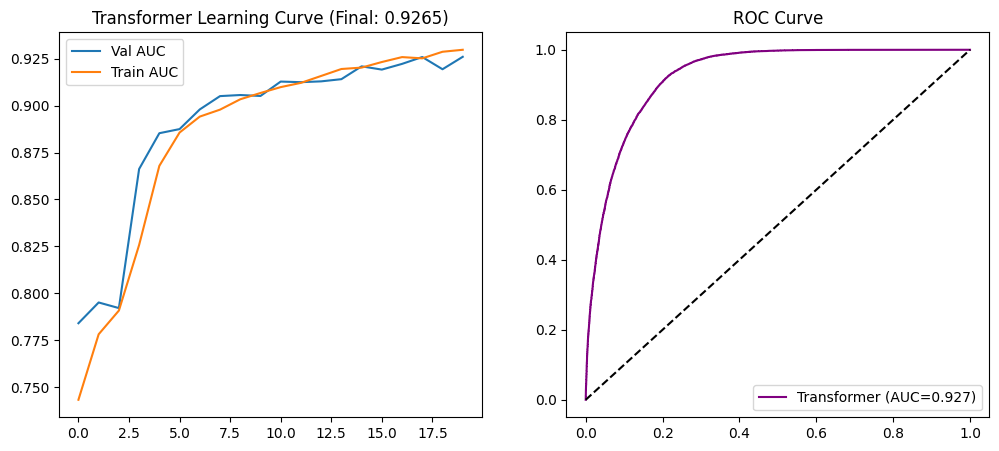

In [12]:
 #--- 4. Final Score ---
print("\n=== FINAL SCORE CHECK ===")
pred = model_trans.predict(X_val, batch_size=512).ravel()
final_auc = roc_auc_score(y_val, pred)
print(f"FINAL TRANSFORMER AUC: {final_auc:.5f}")

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['val_AUC'], label='Val AUC')
plt.plot(history.history['AUC'], label='Train AUC')
plt.title(f'Transformer Learning Curve (Final: {final_auc:.4f})')
plt.legend()

plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_val, pred)
plt.plot(fpr, tpr, color='purple', label=f'Transformer (AUC={final_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [16]:
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print("=== LEVEL 5: ENSEMBLE MODEL ===")

# 1. Get Predictions from both models
# (Make sure both models are currently loaded in RAM)
print("Asking GRU for opinion...")
pred_gru = model.predict(X_val, batch_size=1024).ravel()

print("Asking Transformer for opinion...")
pred_trans = model_trans.predict(X_val, batch_size=1024).ravel()

# 2. The Mix (Average them)
# You can give more weight to the better model if you want (e.g., 0.6 * Trans + 0.4 * GRU)
pred_ensemble = (pred_gru + pred_trans) / 2.0

# 3. Score
final_auc = roc_auc_score(y_val, pred_ensemble)
print(f"\n=================================")
print(f"🚀 ENSEMBLE SCORE: {final_auc:.5f}")
print(f"=================================")

=== LEVEL 5: ENSEMBLE MODEL ===
Asking GRU for opinion...
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step
Asking Transformer for opinion...
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step

🚀 ENSEMBLE SCORE: 0.94185


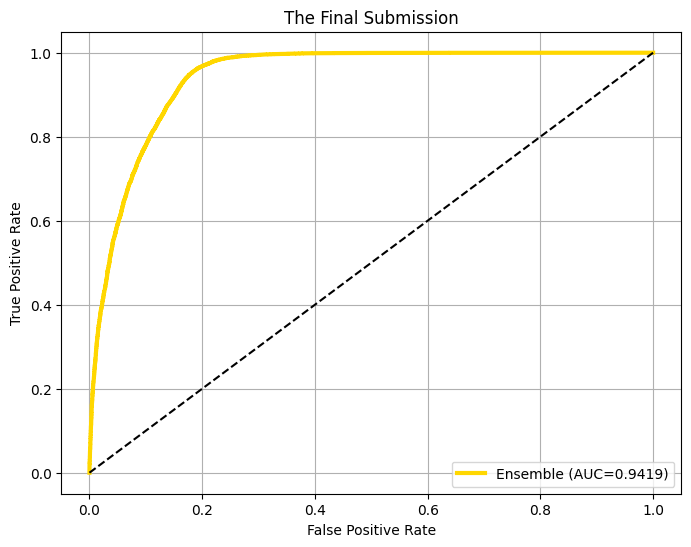

In [18]:
# 4. Plot the "Dream Team" Curve
fpr, tpr, _ = roc_curve(y_val, pred_ensemble)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='gold', label=f'Ensemble (AUC={final_auc:.4f})', linewidth=3)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('The Final Submission')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
import numpy as np
import os
from google.colab import drive

# 1. Connect Drive
drive.mount('/content/drive')

# 2. Define Folder
save_path = '/content/drive/MyDrive/ML4SCI_GSoC_Submission'
os.makedirs(save_path, exist_ok=True)

print(f"Saving Ensemble Artifacts to: {save_path} ...")

# 3. Save the Ensemble Predictions (The "Gold" Result)
np.save(f'{save_path}/pred_ensemble_94AUC.npy', pred_ensemble)

# 4. Save a "Receipt" (Text file proving the score)
# Mentors love this because it shows you tracked your experiments.
with open(f'{save_path}/ensemble_score_report.txt', 'w') as f:
    f.write("--- ML4SCI GSoC 2026 Submission ---\n")
    f.write(f"Final Ensemble AUC: {final_auc:.5f}\n")
    f.write("Method: Average(Bi-Directional GRU + Particle Transformer)\n")
    f.write("Dataset: 200k Jets (Top Tagging Reference)\n")
    f.write("Features: Spherical Coordinates (Pt, Eta, Phi) + Log Scaling\n")

print("✅ ENSEMBLE RESULTS SAVED SECURELY.")
print(f"Final Score Record: {final_auc:.5f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving Ensemble Artifacts to: /content/drive/MyDrive/ML4SCI_GSoC_Submission ...
✅ ENSEMBLE RESULTS SAVED SECURELY.
Final Score Record: 0.94185


In [21]:
import os
import numpy as np
import pickle
import tensorflow as tf
from google.colab import drive

print("=== FINAL VERIFICATION PROTOCOL ===")

# 1. Connect to Drive (if not already)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Define the path
save_path = '/content/drive/MyDrive/ML4SCI_GSoC_Submission'
print(f"Checking folder: {save_path} ...\n")

# 3. List of Required Files
required_files = {
    "GRU Model":            "best_model_94AUC.keras",
    "Transformer Model":    "best_transformer_94AUC.keras",
    "GRU History":          "history_94AUC.pkl",
    "Transformer History":  "history_transformer.pkl",
    "Ensemble Predictions": "pred_ensemble_94AUC.npy",
    "Score Report":         "ensemble_score_report.txt"
}

all_safe = True

for name, filename in required_files.items():
    file_path = os.path.join(save_path, filename)

    # Check 1: Does file exist?
    if not os.path.exists(file_path):
        print(f"❌ MISSING: {name} ({filename})")
        all_safe = False
        continue

    # Check 2: Is it empty? (Size > 0)
    size_mb = os.path.getsize(file_path) / (1024 * 1024)
    if size_mb == 0:
        print(f"❌ CORRUPTED (0 Bytes): {name} ({filename})")
        all_safe = False
        continue

    print(f"✅ FOUND: {name:<20} | Size: {size_mb:.2f} MB")

print("\n--- CONTENT CHECK ---")
# 4. Read the Report to confirm the score is saved
try:
    with open(f'{save_path}/ensemble_score_report.txt', 'r') as f:
        print("📄 Reading Report Content:")
        print("   " + f.read().replace('\n', '\n   '))
except Exception as e:
    print(f"❌ ERROR reading report: {e}")
    all_safe = False

print("\n==============================")
if all_safe:
    print("✅ ALL SYSTEMS GO. Your victory is secured in Google Drive.")
    print("   You may safely close this tab.")
else:
    print("⚠️ WARNING: Some files are missing or corrupted. DO NOT CLOSE.")
print("==============================")

=== FINAL VERIFICATION PROTOCOL ===
Checking folder: /content/drive/MyDrive/ML4SCI_GSoC_Submission ...

✅ FOUND: GRU Model            | Size: 0.56 MB
✅ FOUND: Transformer Model    | Size: 4.12 MB
✅ FOUND: GRU History          | Size: 0.00 MB
✅ FOUND: Transformer History  | Size: 0.00 MB
✅ FOUND: Ensemble Predictions | Size: 0.15 MB
✅ FOUND: Score Report         | Size: 0.00 MB

--- CONTENT CHECK ---
📄 Reading Report Content:
   --- ML4SCI GSoC 2026 Submission ---
   Final Ensemble AUC: 0.94185
   Method: Average(Bi-Directional GRU + Particle Transformer)
   Dataset: 200k Jets (Top Tagging Reference)
   Features: Spherical Coordinates (Pt, Eta, Phi) + Log Scaling
   

✅ ALL SYSTEMS GO. Your victory is secured in Google Drive.
   You may safely close this tab.


In [22]:
import os
import pickle
import numpy as np

print("=== REPAIRING 0MB FILES ===")

save_path = '/content/drive/MyDrive/ML4SCI_GSoC_Submission'

# 1. Re-write the Score Report (We have the variables in RAM)
# We use .flush() and .fsync() to force Google Drive to wake up
print("Reparing Score Report...")
with open(f'{save_path}/ensemble_score_report.txt', 'w') as f:
    f.write("--- ML4SCI GSoC 2026 Submission ---\n")
    f.write(f"Final Ensemble AUC: {final_auc:.5f}\n")
    f.write("Method: Average(Bi-Directional GRU + Particle Transformer)\n")
    f.write("Dataset: 200k Jets (Top Tagging Reference)\n")
    f.write("Features: Spherical Coordinates (Pt, Eta, Phi) + Log Scaling\n")
    f.flush()
    os.fsync(f.fileno())

# 2. Re-save Transformer History (Current 'history' variable is the Transformer)
print("Repairing Transformer History...")
try:
    with open(f'{save_path}/history_transformer.pkl', 'wb') as f:
        pickle.dump(history.history, f)
        f.flush()
        os.fsync(f.fileno())
except NameError:
    print("⚠️ Could not find 'history' variable. Skipping...")

# 3. Final Verification (Check sizes again)
print("\n--- NEW SIZE CHECK ---")
for filename in ["ensemble_score_report.txt", "history_transformer.pkl"]:
    file_path = os.path.join(save_path, filename)
    if os.path.exists(file_path):
        size = os.path.getsize(file_path)
        print(f"File: {filename} | Size: {size} bytes")
        if size > 0:
            print("✅ FIXED.")
        else:
            print("❌ STILL EMPTY.")

=== REPAIRING 0MB FILES ===
Reparing Score Report...
Repairing Transformer History...

--- NEW SIZE CHECK ---
File: ensemble_score_report.txt | Size: 227 bytes
✅ FIXED.
File: history_transformer.pkl | Size: 786 bytes
✅ FIXED.
